In [ ]:
!pip install pandas numpy matplotlib seaborn

我们首先安装一下pandas 然后把脱敏过的数据导入进来看看数据是否完好

In [23]:
import pandas as pd
df = pd.read_csv('safe_data.csv')
df.head()

,编号,开始答题时间,结束答题时间,答题时长,1.您的年龄是？岁,2.您的性别是？,3.您的职业/从属行业是？,4.您的专业是？,5.在日常社交场合中，您更倾向于哪种状态？,6.候选人1:能力感,...,16.如果你认为外貌管理很重要，你认为它背后反映了一个人什么样的特质？:尊重感（是否重视社交场合和对方）,16.如果你认为外貌管理很重要，你认为它背后反映了一个人什么样的特质？:逻辑感（着装是否符合身份与场合逻辑）,16.如果你认为外貌管理很重要，你认为它背后反映了一个人什么样的特质？:不认为外貌能反映任何内在特质,17.在第二页的问卷中，您觉得自己是否受到了候选人外貌风格的影响？,18.我认为一个外表邋遢的人，很难拥有高质量的社交关系。,19.在陌生社交场合（如朋友聚会），你决定是否去认识一个人的主要依据是？,20.在社交/职场中，你认为以下特质的重要性排序是？:专业能力,20.在社交/职场中，你认为以下特质的重要性排序是？:外貌形象,20.在社交/职场中，你认为以下特质的重要性排序是？:性格脾气,20.在社交/职场中，你认为以下特质的重要性排序是？:学历背景
0,37,14-Mar-2026 13:14:50,14-Mar-2026 13:16:56,126,B.12-18,B.女性,A.未就业学生,G.其他,8,C.3,...,D.尊重感（是否重视社交场合和对方）,NaN,NaN,7,10,C.对方的表情（笑容、眼神）是否看起来好接近,2,4,1,3
1,36,11-Mar-2026 15:15:04,11-Mar-2026 15:17:29,145,C.18-24,B.女性,A.未就业学生,A.理学/工学类,5,D.4,...,D.尊重感（是否重视社交场合和对方）,E.逻辑感（着装是否符合身份与场合逻辑）,NaN,8,8,A.对方的长相是否在我的审美点上,1,3,2,4
2,35,11-Mar-2026 13:27:57,11-Mar-2026 13:30:12,135,C.18-24,A.男性,A.未就业学生,B.经济/管理/金融类,1,A.1,...,D.尊重感（是否重视社交场合和对方）,E.逻辑感（着装是否符合身份与场合逻辑）,NaN,7,2,B.对方的穿搭是否体现了某种共同爱好（如同款潮牌、运动感）,1,4,2,3
3,34,11-Mar-2026 12:29:55,11-Mar-2026 12:32:25,150,B.12-18,B.女性,A.未就业学生,A.理学/工学类,5,A.1,...,NaN,NaN,F.不认为外貌能反映任何内在特质,5,10,B.对方的穿搭是否体现了某种共同爱好（如同款潮牌、运动感）,1,4,3,2
4,33,11-Mar-2026 12:11:17,11-Mar-2026 12:20:58,581,C.18-24,B.女性,A.未就业学生,G.其他,5,D.4,...,NaN,E.逻辑感（着装是否符合身份与场合逻辑）,NaN,7,6,C.对方的表情（笑容、眼神）是否看起来好接近,1,3,2,4


这些列名比较长为了方便我们先将这些列名重新命名，且把需要计算的选项先转化为数字类型

In [9]:
import pandas as pd


df = pd.read_csv('safe_data.csv')


rename_dict = {
  
    '6.候选人1:能力感': 'C1_Ability',
    '6.候选人1:亲和力': 'C1_Warmth',
    '6.候选人1:您直觉他的月薪/社会地位高吗？': 'C1_Status',
    
   
    '7.候选人2:能力感': 'C2_Ability',
    '7.候选人2:亲和力': 'C2_Warmth',
    '7.候选人2:您直觉他的月薪/社会地位高吗？': 'C2_Status',
    
  
    '8.候选人3:能力感': 'C3_Ability',
    '8.候选人3:亲和力': 'C3_Warmth',
    '8.候选人3:您直觉他的月薪/社会地位高吗？': 'C3_Status',
    
 
    '9.候选人4:能力感': 'C4_Ability',
    '9.候选人4:亲和力': 'C4_Warmth',
    '9.候选人4:您直觉他的月薪/社会地位高吗？': 'C4_Status',
    
  
    '15.我承认，在资源有限的情况下，我会优先选择看起来更‘像成功人士’的人合作。': 'Q15_Ack',
    '17.在第二页的问卷中，您觉得自己是否受到了候选人外貌风格的影响？': 'Q17_Perception',
    '2.您的性别是？': 'Gender',
    '4.您的专业是？': 'Major',
    '答题时长': 'Duration'
}

df.rename(columns=rename_dict, inplace=True)
calc_cols = [
    'C1_Ability', 'C1_Warmth', 'C1_Status',
    'C2_Ability', 'C2_Warmth', 'C2_Status',
    'C3_Ability', 'C3_Warmth', 'C3_Status',
    'C4_Ability', 'C4_Warmth', 'C4_Status',
    'Q15_Ack', 'Q17_Perception'
]
for col in calc_cols:
    df[col] = df[col].astype(str).str.extract('(\d+)').astype(float)

print("重命名后的核心列名：")
print(df[['C1_Ability', 'C2_Ability', 'Q15_Ack']].columns.tolist())

重命名后的核心列名：
['C1_Ability', 'C2_Ability', 'Q15_Ack']


<>:45: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:45: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\36089\AppData\Local\Temp\ipykernel_63632\4202381983.py:45: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df[col] = df[col].astype(str).str.extract('(\d+)').astype(float)


看上去没问题，那么接下来我们先进行我最感兴趣的那就是看看这些人有多少人心口不一，我们先计算每个人对于这四个形象的打分的方差，先分别计算单个人对于四个形象同一个问题打分(1-5分)的方差，再把三个问题的方差加在一起将用户划分为高差异与低差异。再结合主观承认度的高低，将用户分为四种。

In [13]:

comp_cols = ['C1_Ability', 'C2_Ability', 'C3_Ability', 'C4_Ability']
warm_cols = ['C1_Warmth', 'C2_Warmth', 'C3_Warmth', 'C4_Warmth']
stat_cols = ['C1_Status', 'C2_Status', 'C3_Status', 'C4_Status']

df['V_Ability'] = df[comp_cols].var(axis=1)
df['V_Warmth'] = df[warm_cols].var(axis=1)
df['V_Status'] = df[stat_cols].var(axis=1)

df['Total_Variance'] = df['V_Ability'] + df['V_Warmth'] + df['V_Status']

v_m = df['Total_Variance'].median()
a_m = df['Q15_Ack'].median()

def get_type(row):

    is_high_var = row['Total_Variance'] >= v_m
    is_low_ack = row['Q15_Ack'] < a_m
    
    if is_high_var and is_low_ack: return '高差异低自评'
    if is_high_var and not is_low_ack: return '高差异高自评'
    if not is_high_var and is_low_ack: return '低差异低自评'
    if not is_high_var and not is_low_ack:return '低差异高自评'

df['User_Segment'] = df.apply(get_type, axis=1)

# 看看这四类人各自有多少个？
print(df['User_Segment'].value_counts())

User_Segment
高差异高自评    15
低差异高自评    11
低差异低自评     7
高差异低自评     4
Name: count, dtype: int64


这数据看上去很有趣，我们接下来进行一下可视化

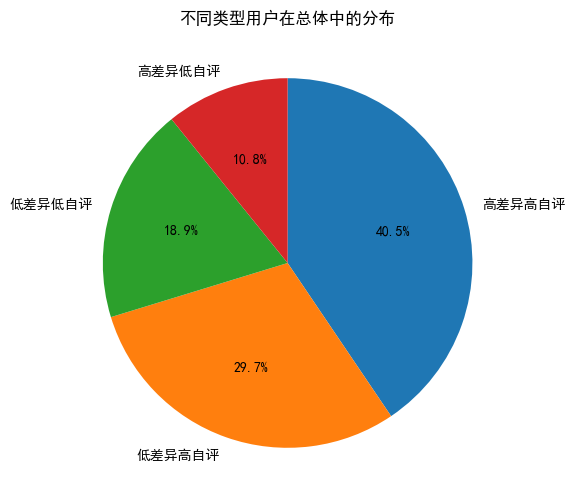

In [16]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(6,6))
df['User_Segment'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, counterclock=False)
plt.title('不同类型用户在总体中的分布')
plt.ylabel('')
plt.show()

可以看到其实有相当一部分人十分坦诚（高自评高差异与低自评低差异）而且公开表示自己以貌取人的人比较多 又有相当一部分人比较“谦虚”说自己以貌取人 但实际上却是对各种外表的人比较包容 只有小部分人嘴上说不看外表，身体很诚实，让我们看看这四个样本有什么共同特征

In [18]:
print(df[df['User_Segment'] == '高差异低自评'][['Gender', 'Major', 'Total_Variance', 'Q15_Ack']])

   Gender        Major  Total_Variance  Q15_Ack
3    B.女性     A.理学/工学类        5.000000      5.0
9    A.男性  E.医学/生物/农林类        4.583333      5.0
16   B.女性          NaN        2.250000      2.0
30   A.男性         G.其他        3.000000      2.0


这标签相当分散了

In [ ]:
接下来研究各个背景下的受访者打分特征分组，也就是看看不同类型的受访者以貌取人的程度如何。

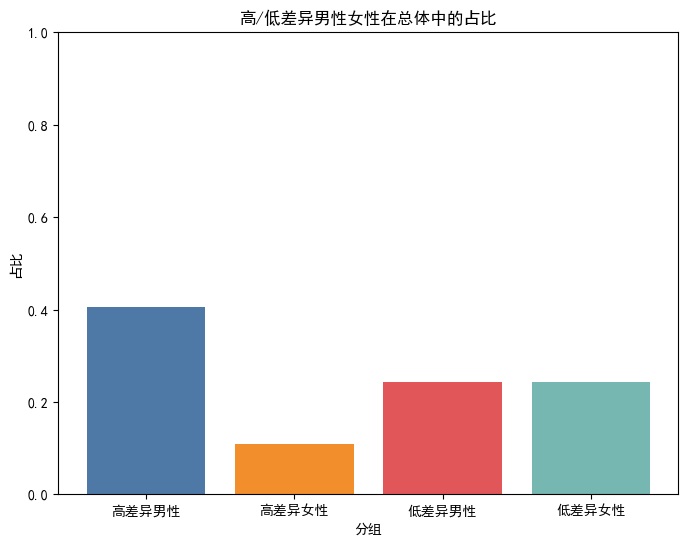

In [25]:
df['Var_Group'] = df['Total_Variance'] >= df['Total_Variance'].median()
df['Var_Group'] = df['Var_Group'].map({True:'高差异', False:'低差异'})
group_labels = ['高差异男性', '高差异女性', '低差异男性', '低差异女性']
group_counts = []
total_count = len(df)
for var_group, gender in [('高差异','A.男性'), ('高差异','B.女性'), ('低差异','A.男性'), ('低差异','B.女性')]:
    count = len(df[(df['Var_Group']==var_group) & (df['Gender']==gender)])
    group_counts.append(count/total_count)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.bar(group_labels, group_counts, color=['#4e79a7','#f28e2b','#e15759','#76b7b2'])
plt.xlabel('分组')
plt.ylabel('占比')
plt.title('高/低差异男性女性在总体中的占比')
plt.ylim(0,1)
plt.show()

我们再来可视化一下是否学生和已经出社会的人在这方面也有差异，由于本人收集数据是本想细分到职业但样本量比较少所以我们直接将身份分为学生以及其他两类

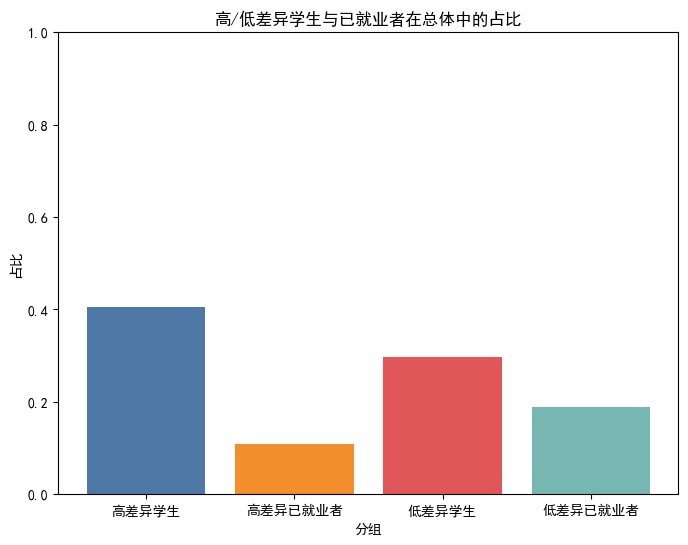

In [26]:
df['身份分组'] = df['3.您的职业/从属行业是？'].apply(lambda x: '学生' if x == 'A.未就业学生' else '已就业者')
df['Var_Group'] = df['Total_Variance'] >= df['Total_Variance'].median()
df['Var_Group'] = df['Var_Group'].map({True:'高差异', False:'低差异'})
group_labels = ['高差异学生', '高差异已就业者', '低差异学生', '低差异已就业者']
group_counts = []
total_count = len(df)
for var_group, status in [('高差异','学生'), ('高差异','已就业者'), ('低差异','学生'), ('低差异','已就业者')]:
    count = len(df[(df['Var_Group']==var_group) & (df['身份分组']==status)])
    group_counts.append(count/total_count)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.bar(group_labels, group_counts, color=['#4e79a7','#f28e2b','#e15759','#76b7b2'])
plt.xlabel('分组')
plt.ylabel('占比')
plt.title('高/低差异学生与已就业者在总体中的占比')
plt.ylim(0,1)
plt.show()

再来看看这个Q20看看大家是否更喜欢和外貌较好的人交往

In [29]:

appearance_rank_col = [c for c in df.columns if '20.' in c and '外貌形象' in c][0]


df['Appearance_Importance'] = df[appearance_rank_col].astype(str).str.extract('(\d+)').astype(float)


df['Is_Appearance_Lover'] = df['Appearance_Importance'] <= 2

<>:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\36089\AppData\Local\Temp\ipykernel_63632\1958474813.py:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df['Appearance_Importance'] = df[appearance_rank_col].astype(str).str.extract('(\d+)').astype(float)


In [32]:

looker_analysis = df.groupby('Is_Appearance_Lover')[['Total_Variance', 'Q15_Ack']].mean()
print("Q20外貌重视程度 vs 实际行为表现：")
print(looker_analysis)


segment_dist = df[df['Is_Appearance_Lover'] == True]['User_Segment'].value_counts()
print("\n重视外貌人群的画像构成：")
print(segment_dist)

Q20外貌重视程度 vs 实际行为表现：
                     Total_Variance   Q15_Ack
Is_Appearance_Lover                          
False                      3.112179  6.653846
True                       3.030303  5.272727

重视外貌人群的画像构成：
User_Segment
高差异高自评    4
低差异低自评    4
低差异高自评    2
高差异低自评    1
Name: count, dtype: int64
